# Лабораторная работа №1
## Первичное исследование и оценка качества данных

**Датасет:** Hotel Booking Demand (`hotel_bookings.csv`)

Цель работы — выполнить первичное исследование датасета, провести аудит качества данных и выполнить мини-EDA.

## 1. Постановка задачи

### Что это за данные
Датасет содержит сведения о бронированиях двух типов отелей: `City Hotel` и `Resort Hotel`. Для каждого бронирования указаны сроки и параметры проживания, сведения о гостях, стране, способе оформления бронирования, типе номера, стоимости и статусе бронирования. Также присутствуют даты, поэтому данные можно анализировать во временном разрезе.

### Условный заказчик
Условным заказчиком анализа может выступать руководство гостиничной сети или команда по управлению бронированиями и доходностью.

### Возможные задачи интеллектуального анализа данных
1. Анализировать факторы, связанные с отменой бронирований.
2. Выполнять сегментацию бронирований по типу отеля, каналам продаж, типам клиентов и другим характеристикам.
3. Выявлять аномальные или подозрительные записи, например необычные значения стоимости или количества гостей.
4. Проводить описательную аналитику по сезонности и структуре бронирований.

## 2. Паспорт датасета

В этой работе сначала фиксируются исходные типы столбцов, а затем отдельные временные признаки приводятся к более подходящему типу. Описание смысла признаков ниже является рабочей гипотезой по названию столбца, так как отдельного словаря признаков в исходном CSV нет.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ищем датасет автоматически, чтобы ноутбук можно было запускать
# как из корня проекта, так и из папки notebooks.
paths = [
    Path("data/hotel_bookings.csv"),
    Path("../data/hotel_bookings.csv"),
]

cwd = Path.cwd()
for parent in [cwd, *cwd.parents]:
    paths.append(parent / "data" / "hotel_bookings.csv")

path = next((p.resolve() for p in paths if p.exists()), None)
if path is None:
    raise FileNotFoundError(
        "Не найден data/hotel_bookings.csv. Запустите ноутбук внутри репозитория, "
        "где рядом с ним находится папка data."
    )

print("Файл данных:", path)
df = pd.read_csv(path)

print("Размер датасета:", df.shape)
display(df.head())

Файл данных: /mnt/data/hotel_bookings_lab1_updated/data/hotel_bookings.csv
Размер датасета: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
# Полный паспорт признаков.
# Смысл каждого признака сформулирован как гипотеза по названию столбца.
desc = {
    "hotel": "Тип отеля: City Hotel или Resort Hotel.",
    "is_canceled": "Факт отмены бронирования (1 — отменено, 0 — не отменено).",
    "lead_time": "Количество дней между бронированием и датой заезда.",
    "arrival_date_year": "Год планируемого заезда.",
    "arrival_date_month": "Месяц планируемого заезда.",
    "arrival_date_week_number": "Номер недели года для даты заезда.",
    "arrival_date_day_of_month": "День месяца планируемого заезда.",
    "stays_in_weekend_nights": "Количество ночей проживания в выходные дни.",
    "stays_in_week_nights": "Количество ночей проживания в будние дни.",
    "adults": "Количество взрослых гостей.",
    "children": "Количество детей.",
    "babies": "Количество младенцев.",
    "meal": "Тип питания, включённого в бронирование.",
    "country": "Страна происхождения гостя/рынка бронирования.",
    "market_segment": "Сегмент рынка, к которому относится бронирование.",
    "distribution_channel": "Канал распространения/продажи бронирования.",
    "is_repeated_guest": "Признак повторного гостя (1 — повторный, 0 — нет).",
    "previous_cancellations": "Количество предыдущих отмен бронирований гостя.",
    "previous_bookings_not_canceled": "Количество предыдущих неотменённых бронирований гостя.",
    "reserved_room_type": "Тип номера, забронированный клиентом.",
    "assigned_room_type": "Тип номера, фактически назначенный клиенту.",
    "booking_changes": "Количество изменений, внесённых в бронирование.",
    "deposit_type": "Тип внесённого депозита/условий предоплаты.",
    "agent": "Идентификатор агента, через которого оформлено бронирование; NaN может означать отсутствие агента.",
    "company": "Идентификатор компании, связанной с бронированием; NaN может означать отсутствие компании.",
    "days_in_waiting_list": "Количество дней нахождения бронирования в листе ожидания.",
    "customer_type": "Тип клиента по классификации датасета.",
    "adr": "Средняя суточная стоимость проживания (Average Daily Rate).",
    "required_car_parking_spaces": "Количество требуемых парковочных мест.",
    "total_of_special_requests": "Количество специальных запросов клиента.",
    "reservation_status": "Итоговый статус бронирования.",
    "reservation_status_date": "Дата последнего изменения статуса бронирования."
}

passport = pd.DataFrame({
    "Признак": df.columns,
    "Тип pandas": [str(df[c].dtype) for c in df.columns],
    "Количество уникальных": [df[c].nunique(dropna=True) for c in df.columns],
    "Пропуски": [df[c].isna().sum() for c in df.columns],
    "Смысл / рабочая гипотеза": [desc[c] for c in df.columns]
})

display(passport)

,Признак,Тип pandas,Количество уникальных,Пропуски,Смысл / рабочая гипотеза
0,hotel,object,2,0,Тип отеля: City Hotel или Resort Hotel.
1,is_canceled,int64,2,0,"Факт отмены бронирования (1 — отменено, 0 — не..."
2,lead_time,int64,479,0,Количество дней между бронированием и датой за...
3,arrival_date_year,int64,3,0,Год планируемого заезда.
4,arrival_date_month,object,12,0,Месяц планируемого заезда.
5,arrival_date_week_number,int64,53,0,Номер недели года для даты заезда.
6,arrival_date_day_of_month,int64,31,0,День месяца планируемого заезда.
7,stays_in_weekend_nights,int64,17,0,Количество ночей проживания в выходные дни.
8,stays_in_week_nights,int64,35,0,Количество ночей проживания в будние дни.
9,adults,int64,14,0,Количество взрослых гостей.


In [3]:
# Приведение временных признаков к более подходящим типам.
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"], errors="coerce"
)

months = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df["arrival_month_num"] = df["arrival_date_month"].map(months)
df["arrival_date"] = pd.to_datetime(
    dict(
        year=df["arrival_date_year"],
        month=df["arrival_month_num"],
        day=df["arrival_date_day_of_month"]
    ),
    errors="coerce"
)

print("Типы после приведения дат:")
display(df[["reservation_status_date", "arrival_date"]].dtypes.to_frame("Тип pandas"))
display(df[["arrival_date", "reservation_status_date"]].head())

Типы после приведения дат:


,Тип pandas
reservation_status_date,datetime64[ns]
arrival_date,datetime64[ns]


,arrival_date,reservation_status_date
0,2015-07-01,2015-07-01
1,2015-07-01,2015-07-01
2,2015-07-01,2015-07-02
3,2015-07-01,2015-07-02
4,2015-07-01,2015-07-03


## 3. Аудит качества данных
### 3.1. Пропуски

In [4]:
missing = pd.DataFrame({
    "Количество пропусков": df.isna().sum(),
    "Доля пропусков, %": (df.isna().mean() * 100).round(2)
}).sort_values("Количество пропусков", ascending=False)

display(missing[missing["Количество пропусков"] > 0])

,Количество пропусков,"Доля пропусков, %"
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


**Вывод.** Наибольшая проблема — столбец `company`: в нём отсутствуют значения примерно в 94,3% строк. Также заметная доля пропусков есть в `agent` (около 13,7%). В `country` пропуски составляют около 0,4%, а в `children` — только 4 записи. При дальнейшем анализе пропуски нужно обрабатывать с учётом смысла признака, а не автоматически заменять одним значением.

### 3.2. Дубликаты

In [5]:
dups = df.duplicated().sum()
print("Количество полностью дублирующихся строк:", dups)
print("Доля дубликатов, %:", round(dups / len(df) * 100, 2))

Количество полностью дублирующихся строк: 31994
Доля дубликатов, %: 26.8


**Вывод.** В датасете обнаружено 31 994 полностью дублирующиеся строки. Это существенно больше нуля, поэтому перед построением моделей необходимо определить, являются ли такие записи действительно повторными наблюдениями или отражают разные бронирования с одинаковым набором признаков.

### 3.3. Числовые и категориальные признаки

In [6]:
nums = df.select_dtypes(include="number").columns
cats = df.select_dtypes(include="object").columns

print("Числовые признаки:")
display(df[nums].describe().T)

print("Категориальные признаки:")
cat = pd.DataFrame({
    "Уникальных значений": [df[c].nunique(dropna=True) for c in cats],
    "Пропусков": [df[c].isna().sum() for c in cats]
}, index=cats)
display(cat)

Числовые признаки:


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


Категориальные признаки:


,Уникальных значений,Пропусков
hotel,2,0
arrival_date_month,12,0
meal,5,0
country,177,488
market_segment,8,0
distribution_channel,5,0
reserved_room_type,10,0
assigned_room_type,12,0
deposit_type,3,0
customer_type,4,0


In [7]:
# Проверка подозрительных значений в числовых и специальных категориях.
chk = pd.Series({
    "Отрицательный lead_time": (df["lead_time"] < 0).sum(),
    "Отрицательный ADR": (df["adr"] < 0).sum(),
    "Нулевая группа гостей": (
        (df["adults"].fillna(0) + df["children"].fillna(0) + df["babies"].fillna(0)) == 0
    ).sum(),
    "Нулевое количество взрослых": (df["adults"] == 0).sum(),
    "Необычные годы заезда": (~df["arrival_date_year"].isin([2015, 2016, 2017])).sum(),
    "Undefined в meal": (df["meal"] == "Undefined").sum(),
    "Undefined в market_segment": (df["market_segment"] == "Undefined").sum(),
    "Undefined в distribution_channel": (df["distribution_channel"] == "Undefined").sum()
})
display(chk.to_frame("Количество"))

,Количество
Отрицательный lead_time,0
Отрицательный ADR,1
Нулевая группа гостей,180
Нулевое количество взрослых,403
Необычные годы заезда,0
Undefined в meal,1169
Undefined в market_segment,2
Undefined в distribution_channel,5


### Проверка «грязных» категорий

Для категориальных признаков выполняется отдельная проверка на лишние пробелы и на ситуации, когда разные записи становятся одинаковыми после удаления пробелов и приведения регистра. Это не доказывает наличие смысловых дубликатов категорий, но является простым автоматическим скринингом качества.

In [8]:
dirty = []
for col in cats:
    s = df[col].dropna().astype(str)
    spaces = int((s != s.str.strip()).sum())
    norm = s.str.strip().str.casefold()
    groups = pd.DataFrame({"original": s, "norm": norm}).groupby("norm")["original"].nunique()
    variants = int((groups > 1).sum())
    dirty.append({
        "Признак": col,
        "Значений с лишними пробелами": spaces,
        "Групп, совпадающих после strip + casefold": variants
    })

dirty_cat = pd.DataFrame(dirty).sort_values(
    ["Значений с лишними пробелами", "Групп, совпадающих после strip + casefold"],
    ascending=False
)
display(dirty_cat)

# Дополнительно покажем категории Undefined, если они присутствуют.
undef = []
for col in cats:
    count = int((df[col].astype(str).str.strip() == "Undefined").sum())
    if count:
        undef.append({"Признак": col, "Undefined": count})

if undef:
    print("Категории Undefined:")
    display(pd.DataFrame(undef))
else:
    print("Категории Undefined не обнаружены.")

,Признак,Значений с лишними пробелами,"Групп, совпадающих после strip + casefold"
0,hotel,0,0
1,arrival_date_month,0,0
2,meal,0,0
3,country,0,0
4,market_segment,0,0
5,distribution_channel,0,0
6,reserved_room_type,0,0
7,assigned_room_type,0,0
8,deposit_type,0,0
9,customer_type,0,0


Категории Undefined:


,Признак,Undefined
0,meal,1169
1,market_segment,2
2,distribution_channel,5


**Вывод.** Проверка категорий показывает, есть ли технические признаки «грязных» значений: лишние пробелы и различия только в регистре. Такие случаи следует нормализовать перед группировками. Отдельно проверяются значения `Undefined`: в данном датасете они присутствуют в некоторых категориальных признаках и требуют осмысленного решения по обработке. По этой проверке нельзя автоматически считать разные категории ошибкой без проверки их смысла.

**Вывод по числовым и подозрительным значениям.** Обнаружена как минимум одна явно подозрительная запись с отрицательным `adr` (-6,38). Кроме того, 180 строк имеют нулевое суммарное количество гостей, а 403 строки — ноль взрослых. Такие записи требуют отдельной проверки перед дальнейшим анализом. Категории `Undefined` также требуют документированного решения по обработке.

### 3.4. Выбросы методом IQR

In [9]:
def iqr_out(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data[column] < lower) | (data[column] > upper)
    return q1, q3, iqr, lower, upper, mask

q1, q3, iqr, lower, upper, out_mask = iqr_out(df, "adr")
print(f"Q1 = {q1:.2f}")
print(f"Q3 = {q3:.2f}")
print(f"IQR = {iqr:.2f}")
print(f"Нижняя граница = {lower:.2f}")
print(f"Верхняя граница = {upper:.2f}")
print("Количество выбросов ADR:", out_mask.sum())

display(df.loc[out_mask, ["hotel", "adr", "adults", "children", "babies", "is_canceled"]].head(20))

Q1 = 69.29
Q3 = 126.00
IQR = 56.71
Нижняя граница = -15.77
Верхняя граница = 211.06
Количество выбросов ADR: 3793


,hotel,adr,adults,children,babies,is_canceled
140,Resort Hotel,225.00,3,0.0,0,0
303,Resort Hotel,213.75,2,2.0,0,0
396,Resort Hotel,230.67,2,2.0,0,0
412,Resort Hotel,216.13,2,2.0,0,0
523,Resort Hotel,249.00,2,2.0,0,0
526,Resort Hotel,241.50,2,1.0,0,0
558,Resort Hotel,214.00,2,2.0,0,1
580,Resort Hotel,214.00,2,2.0,0,1
584,Resort Hotel,240.64,2,1.0,0,1
632,Resort Hotel,217.05,3,0.0,0,0


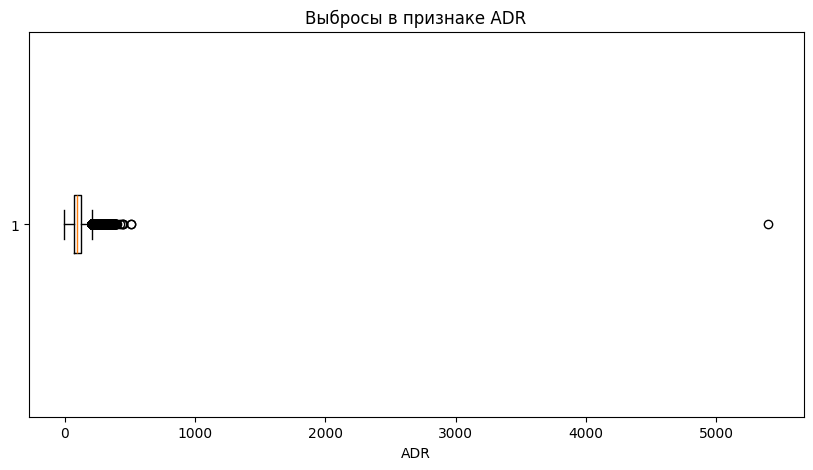

In [10]:
plt.figure(figsize=(10, 5))
plt.boxplot(df["adr"].dropna(), vert=False)
plt.xlabel("ADR")
plt.title("Выбросы в признаке ADR")
plt.show()

**Вывод.** По правилу IQR для `adr` получено 3 793 наблюдения вне интервала [−15,77; 211,07]. Это статистические выбросы, а не автоматически ошибки: часть высоких значений может отражать реальные дорогие бронирования. Отрицательное значение `adr` отдельно выглядит подозрительно и требует проверки.

## 4. Разведочный анализ

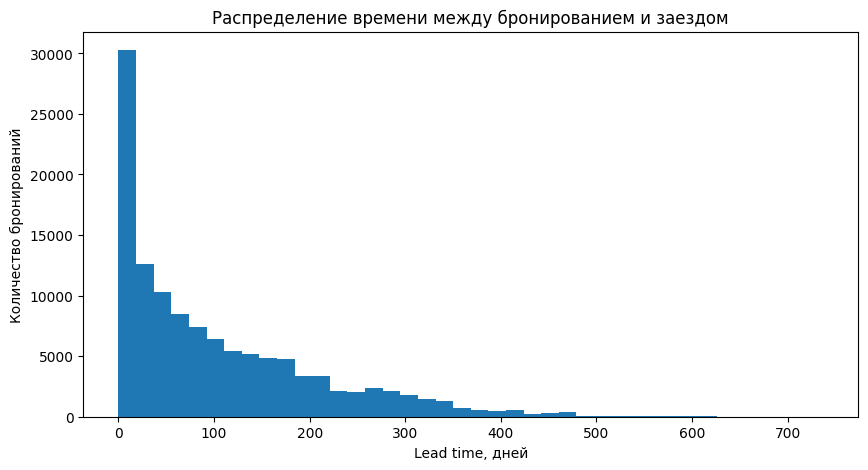

In [11]:
# 1. Распределение ключевого числового признака
plt.figure(figsize=(10, 5))
plt.hist(df["lead_time"], bins=40)
plt.xlabel("Lead time, дней")
plt.ylabel("Количество бронирований")
plt.title("Распределение времени между бронированием и заездом")
plt.show()

**Комментарий.** Большая часть бронирований имеет относительно небольшое или среднее время предварительного бронирования, однако распределение имеет длинный правый хвост. Это показывает, что существуют бронирования, сделанные значительно заранее. Возникает гипотеза, что длительный `lead_time` может быть связан с вероятностью отмены.

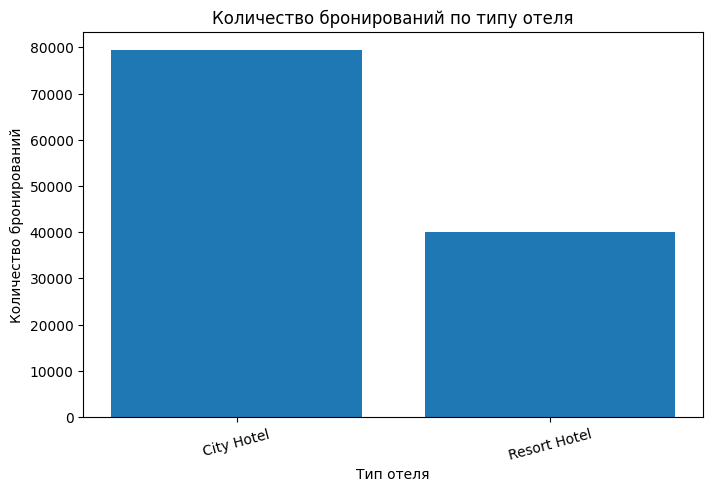

In [12]:
# 2. Распределение категориального признака
hotels = df["hotel"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(hotels.index, hotels.values)
plt.xlabel("Тип отеля")
plt.ylabel("Количество бронирований")
plt.title("Количество бронирований по типу отеля")
plt.xticks(rotation=15)
plt.show()

**Комментарий.** В датасете значительно больше бронирований для `City Hotel`, чем для `Resort Hotel`. Это означает, что общие показатели в первую очередь отражают структуру городского отеля. Для корректных сравнений полезно анализировать два типа отелей отдельно.

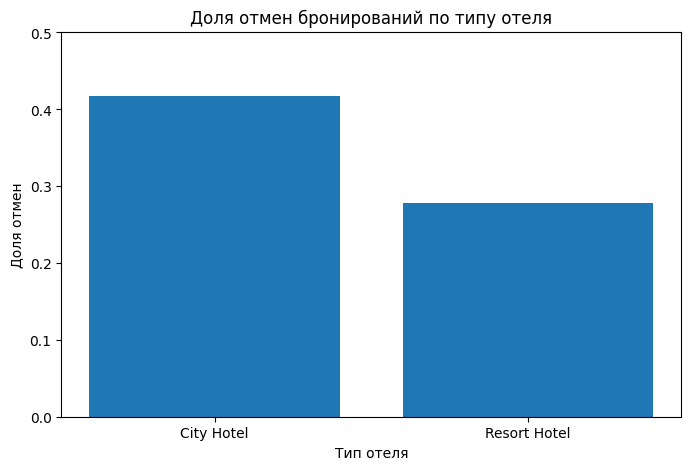

,"Доля отмен, %"
hotel,
City Hotel,41.73
Resort Hotel,27.76


In [13]:
# 3. Зависимость между признаками: отмена по типу отеля
cancel = df.groupby("hotel")["is_canceled"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(cancel.index, cancel.values)
plt.xlabel("Тип отеля")
plt.ylabel("Доля отмен")
plt.title("Доля отмен бронирований по типу отеля")
plt.ylim(0, max(cancel.values) * 1.2)
plt.show()

display((cancel * 100).round(2).to_frame("Доля отмен, %"))

**Комментарий.** Доля отмен различается между двумя типами отелей: для `City Hotel` она составляет около 41,7%, для `Resort Hotel` — около 27,8%. Это наблюдение не доказывает причинную связь, но показывает, что тип отеля является полезным признаком для дальнейшего исследования отмен.

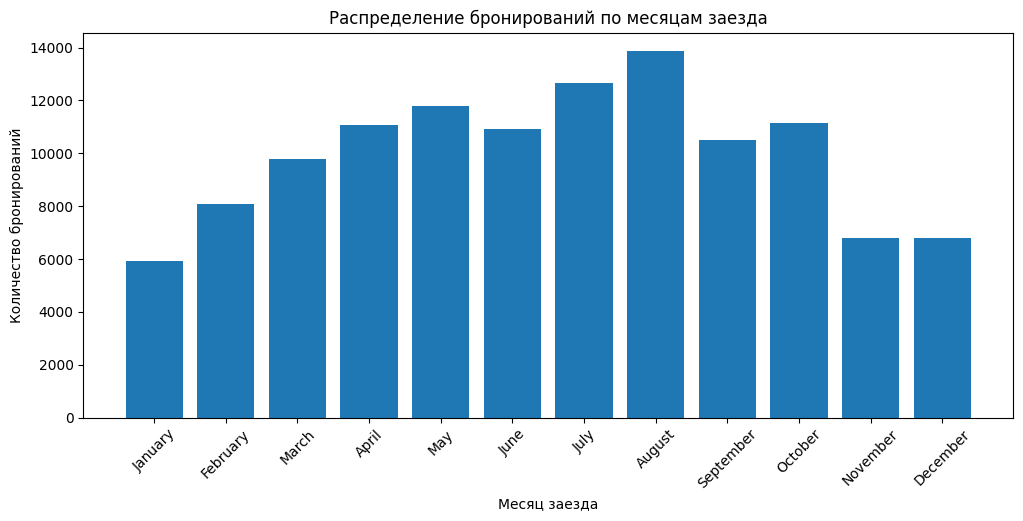

In [14]:
# Дополнительная визуализация: сезонность
m_order = list(months.keys())
monthly = df["arrival_date_month"].value_counts().reindex(m_order)

plt.figure(figsize=(12, 5))
plt.bar(monthly.index, monthly.values)
plt.xlabel("Месяц заезда")
plt.ylabel("Количество бронирований")
plt.title("Распределение бронирований по месяцам заезда")
plt.xticks(rotation=45)
plt.show()

**Комментарий.** Количество бронирований заметно меняется по месяцам. Наибольшее число наблюдений приходится на август и июль, а наименьшее — на январь. Это указывает на выраженную сезонность и позволяет в дальнейшем исследовать связь сезона с типом отеля, стоимостью и отменами.

## Итоговые выводы

В результате первичного исследования установлено, что датасет содержит 119 390 строк и 32 исходных признака, включая числовые, категориальные и временные признаки. Основные проблемы качества — большое количество пропусков в `company`, заметные пропуски в `agent`, наличие пропусков в `country` и `children`, а также 31 994 полных дубликата.

Отдельной проверки требуют подозрительные значения: отрицательный `adr`, записи с нулевым количеством гостей и категории `Undefined`. Метод IQR выявил 3 793 статистических выброса в `adr`. На этапе дальнейшей обработки следует определить правила удаления или корректировки дубликатов и аномалий, отдельно решить вопрос с пропусками и проверить влияние очистки на результаты анализа.